In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# **Introduction**

Artificial Intelligence tools like ChatGPT, Claude, and Copilot are rapidly reshaping how students learn, write, and code.

In this notebook, we explore how AI usage affects:
📈 Academic performance (GPA changes).
🧑‍💻 Student behavior.
🧠 Career confidence & ethics concerns.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [5]:
df = pd.read_csv(r"C:\Users\Vanshika\Downloads\AI_Impact_Student_Life_2026.csv")

In [6]:
df.head()

,Student_ID,Age,Major,Primary_AI_Tool,Task_Frequency_Daily,Main_Usage_Case,GPA_Baseline,GPA_Post_AI,Time_Saved_Hours_Weekly,AI_Ethics_Concern,Career_Confidence_Score
0,STU-6019,23,Software Engineering,Gemini Pro,1,Code Debugging,2.62,2.62,9,Medium,3
1,STU-6962,22,Modern History,GitHub Copilot,3,Essay Drafting,3.99,4.00,7,Medium,4
2,STU-2338,18,Data Science,Perplexity,2,Literature Review,2.57,2.57,15,High,7
3,STU-1380,19,Biology,Claude 3.5,5,Essay Drafting,2.67,2.87,12,Low,5
4,STU-1837,19,Biology,ChatGPT-4o,10,Code Debugging,3.65,3.85,5,High,9


In [7]:
df.tail()

,Student_ID,Age,Major,Primary_AI_Tool,Task_Frequency_Daily,Main_Usage_Case,GPA_Baseline,GPA_Post_AI,Time_Saved_Hours_Weekly,AI_Ethics_Concern,Career_Confidence_Score
1495,STU-2711,21,Modern History,GitHub Copilot,4,Brainstorming,3.35,3.55,7,Medium,7
1496,STU-4888,21,Biology,GitHub Copilot,3,Essay Drafting,3.59,3.89,13,Medium,7
1497,STU-0180,23,Software Engineering,GitHub Copilot,8,Code Debugging,3.20,3.40,7,Low,2
1498,STU-4392,23,Fine Arts,Perplexity,6,Brainstorming,3.99,4.00,15,Low,7
1499,STU-4702,23,Data Science,Gemini Pro,4,Exam Prep,3.53,3.43,3,Medium,8


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Student_ID               1500 non-null   object 
 1   Age                      1500 non-null   int64  
 2   Major                    1500 non-null   object 
 3   Primary_AI_Tool          1500 non-null   object 
 4   Task_Frequency_Daily     1500 non-null   int64  
 5   Main_Usage_Case          1500 non-null   object 
 6   GPA_Baseline             1500 non-null   float64
 7   GPA_Post_AI              1500 non-null   float64
 8   Time_Saved_Hours_Weekly  1500 non-null   int64  
 9   AI_Ethics_Concern        1500 non-null   object 
 10  Career_Confidence_Score  1500 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 129.0+ KB


In [9]:
df.describe()

,Age,Task_Frequency_Daily,GPA_Baseline,GPA_Post_AI,Time_Saved_Hours_Weekly,Career_Confidence_Score
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000,1500.000000
mean,21.494000,5.407333,3.256853,3.344587,8.51000,5.417333
std,2.297277,2.905462,0.430583,0.437409,4.07148,2.844977
min,18.000000,1.000000,2.500000,2.400000,2.00000,1.000000
25%,20.000000,3.000000,2.880000,2.980000,5.00000,3.000000
50%,21.000000,5.000000,3.260000,3.360000,9.00000,5.000000
75%,23.000000,8.000000,3.620000,3.710000,12.00000,8.000000
max,25.000000,10.000000,4.000000,4.000000,15.00000,10.000000


In [10]:
df['Age']

0       23
1       22
2       18
3       19
4       19
        ..
1495    21
1496    21
1497    23
1498    23
1499    23
Name: Age, Length: 1500, dtype: int64

In [11]:
df["Age"].unique()

array([23, 22, 18, 19, 20, 24, 21, 25], dtype=int64)

In [12]:
df.columns

Index(['Student_ID', 'Age', 'Major', 'Primary_AI_Tool', 'Task_Frequency_Daily',
       'Main_Usage_Case', 'GPA_Baseline', 'GPA_Post_AI',
       'Time_Saved_Hours_Weekly', 'AI_Ethics_Concern',
       'Career_Confidence_Score'],
      dtype='object')

In [13]:
df.isnull().sum()

Student_ID                 0
Age                        0
Major                      0
Primary_AI_Tool            0
Task_Frequency_Daily       0
Main_Usage_Case            0
GPA_Baseline               0
GPA_Post_AI                0
Time_Saved_Hours_Weekly    0
AI_Ethics_Concern          0
Career_Confidence_Score    0
dtype: int64

In [14]:
df.dropna()

,Student_ID,Age,Major,Primary_AI_Tool,Task_Frequency_Daily,Main_Usage_Case,GPA_Baseline,GPA_Post_AI,Time_Saved_Hours_Weekly,AI_Ethics_Concern,Career_Confidence_Score
0,STU-6019,23,Software Engineering,Gemini Pro,1,Code Debugging,2.62,2.62,9,Medium,3
1,STU-6962,22,Modern History,GitHub Copilot,3,Essay Drafting,3.99,4.00,7,Medium,4
2,STU-2338,18,Data Science,Perplexity,2,Literature Review,2.57,2.57,15,High,7
3,STU-1380,19,Biology,Claude 3.5,5,Essay Drafting,2.67,2.87,12,Low,5
4,STU-1837,19,Biology,ChatGPT-4o,10,Code Debugging,3.65,3.85,5,High,9
...,...,...,...,...,...,...,...,...,...,...,...
1495,STU-2711,21,Modern History,GitHub Copilot,4,Brainstorming,3.35,3.55,7,Medium,7
1496,STU-4888,21,Biology,GitHub Copilot,3,Essay Drafting,3.59,3.89,13,Medium,7
1497,STU-0180,23,Software Engineering,GitHub Copilot,8,Code Debugging,3.20,3.40,7,Low,2
1498,STU-4392,23,Fine Arts,Perplexity,6,Brainstorming,3.99,4.00,15,Low,7


The dataset contains student demographics, AI usage patterns, and academic performance before and after AI adoption.

# **Feature Engineering**

In [15]:
# GPA Change already exists, but ensure it's correct
df["GPA_Change"] = df["GPA_Post_AI"] - df["GPA_Baseline"]

# Categorize usage intensity
df["Usage_Level"] = pd.cut(
    df["Task_Frequency_Daily"],
    bins=[0, 2, 5, 10],
    labels=["Low", "Medium", "High"]
)

# **🎯 GPA Improvement Distribution**

Most students show slight improvement, but some experience no change or decline.

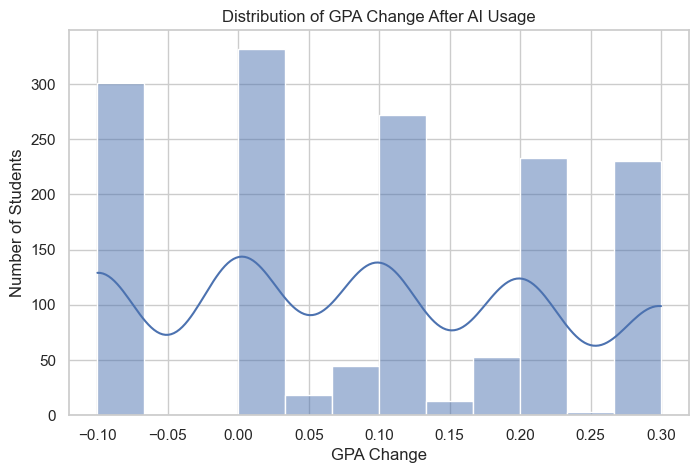

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df["GPA_Change"], kde=True)
plt.xlabel("GPA Change")
plt.ylabel("Number of Students")
plt.title("Distribution of GPA Change After AI Usage")
plt.show()

# **🤖 AI Tool vs GPA Change**

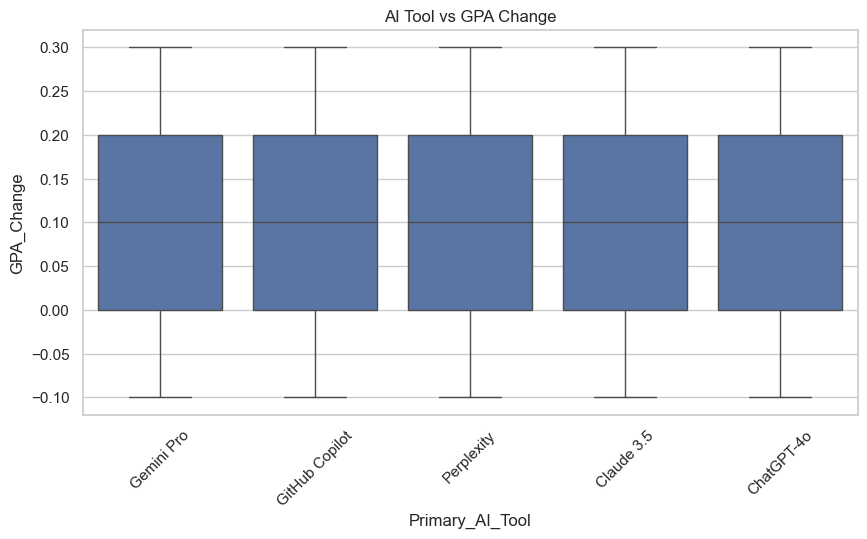

In [17]:
plt.figure(figsize=(10,5))
sns.boxplot(x="Primary_AI_Tool", y="GPA_Change", data=df)
plt.xticks(rotation=45)
plt.title("AI Tool vs GPA Change")
plt.show()

Some tools appear more associated with GPA improvement—but correlation ≠ causation.

# **🎓 Major vs AI Adoption**

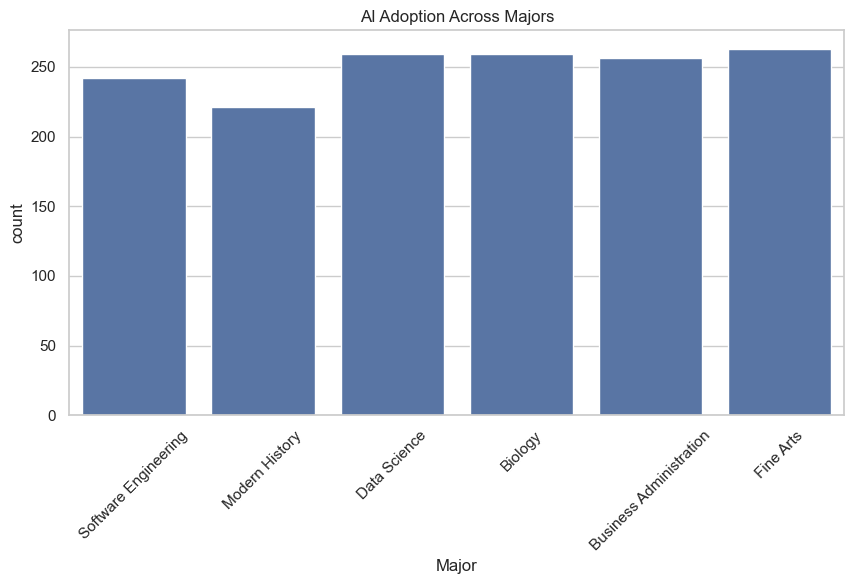

In [18]:
plt.figure(figsize=(10,5))
sns.countplot(x="Major", data=df)
plt.xticks(rotation=45)
plt.title("AI Adoption Across Majors")
plt.show()

# **⏱ Time Saved vs Career Confidence**

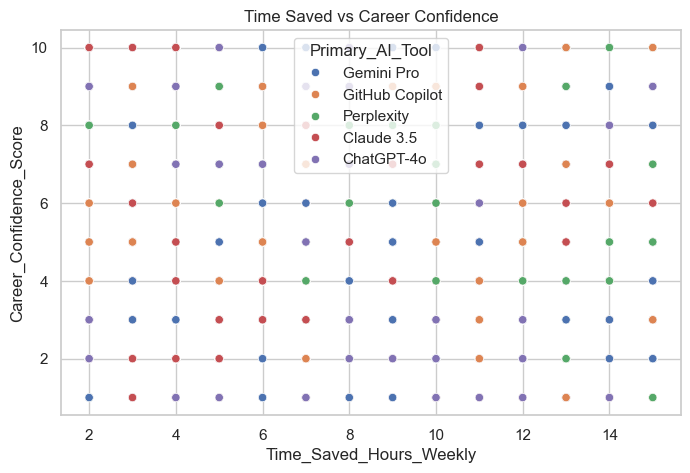

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x="Time_Saved_Hours_Weekly",
    y="Career_Confidence_Score",
    hue="Primary_AI_Tool",
    data=df
)
plt.title("Time Saved vs Career Confidence")
plt.show()

Students saving more time tend to feel more career-ready.

# **Ethics vs Usage**

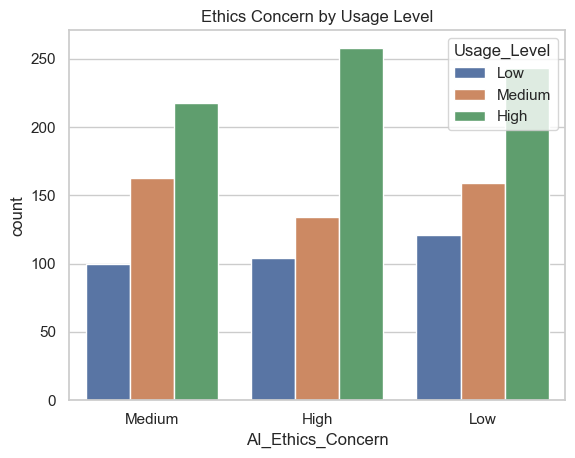

In [20]:
sns.countplot(x="AI_Ethics_Concern", hue="Usage_Level", data=df)
plt.title("Ethics Concern by Usage Level")
plt.show()

Heavy users may show different ethical concerns compared to light users.

In [21]:
df_model = df.copy()

# Drop ID early
df_model = df_model.drop("Student_ID", axis=1)

# One-hot encode ALL categorical columns
df_model = pd.get_dummies(df_model, drop_first=True)

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

df_model = df.copy()

# Drop ID
df_model = df_model.drop("Student_ID", axis=1)

# Convert categorical → numeric
df_model = pd.get_dummies(df_model, drop_first=True)

# Split features & target
X = df_model.drop("Career_Confidence_Score", axis=1)
y = df_model["Career_Confidence_Score"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Score
print("Model Score:", model.score(X_test, y_test))

Model Score: -0.05640445648075132


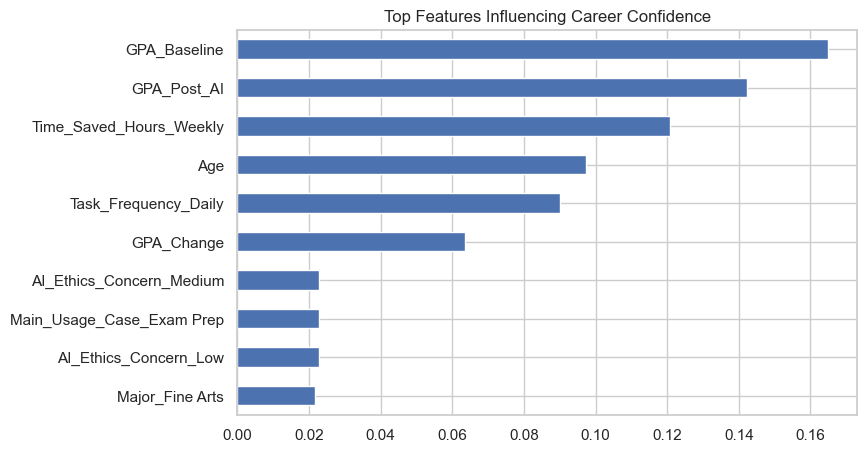

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().tail(10).plot(kind='barh', figsize=(8,5))
plt.title("Top Features Influencing Career Confidence")
plt.show()

<Axes: >

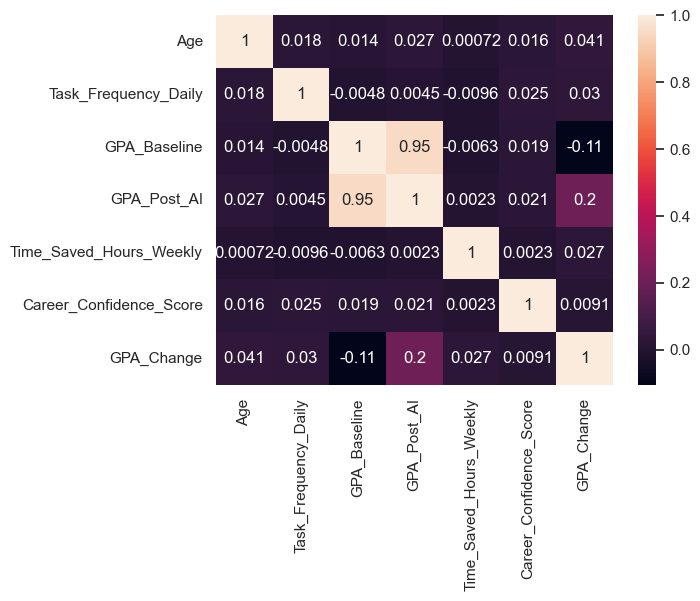

In [24]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [26]:
df_model = df.copy()

# Drop ID
df_model = df_model.drop("Student_ID", axis=1)

# One-hot encoding
df_model = pd.get_dummies(df_model, drop_first=True)

# Handle missing values (if any)
df_model = df_model.fillna(df_model.mean(numeric_only=True))

df_model.head()

,Age,Task_Frequency_Daily,GPA_Baseline,GPA_Post_AI,Time_Saved_Hours_Weekly,Career_Confidence_Score,GPA_Change,Major_Business Administration,Major_Data Science,Major_Fine Arts,...,Primary_AI_Tool_GitHub Copilot,Primary_AI_Tool_Perplexity,Main_Usage_Case_Code Debugging,Main_Usage_Case_Essay Drafting,Main_Usage_Case_Exam Prep,Main_Usage_Case_Literature Review,AI_Ethics_Concern_Low,AI_Ethics_Concern_Medium,Usage_Level_Medium,Usage_Level_High
0,23,1,2.62,2.62,9,3,0.00,False,False,False,...,False,False,True,False,False,False,False,True,False,False
1,22,3,3.99,4.00,7,4,0.01,False,False,False,...,True,False,False,True,False,False,False,True,True,False
2,18,2,2.57,2.57,15,7,0.00,False,True,False,...,False,True,False,False,False,True,False,False,False,False
3,19,5,2.67,2.87,12,5,0.20,False,False,False,...,False,False,False,True,False,False,True,False,True,False
4,19,10,3.65,3.85,5,9,0.20,False,False,False,...,False,False,True,False,False,False,False,False,False,True


# **XGBoost Model (Predict Career Confidence)**

In [27]:
# !pip install xgboost

In [28]:
import sys
print(sys.executable)

c:\Users\Vanshika\.jupyter\New folder\python.exe


In [29]:
#Model
from xgboost import XGBRegressor

X = df_model.drop("Career_Confidence_Score", axis=1)
y = df_model["Career_Confidence_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: -0.06997370719909668
RMSE: 2.944495786887517


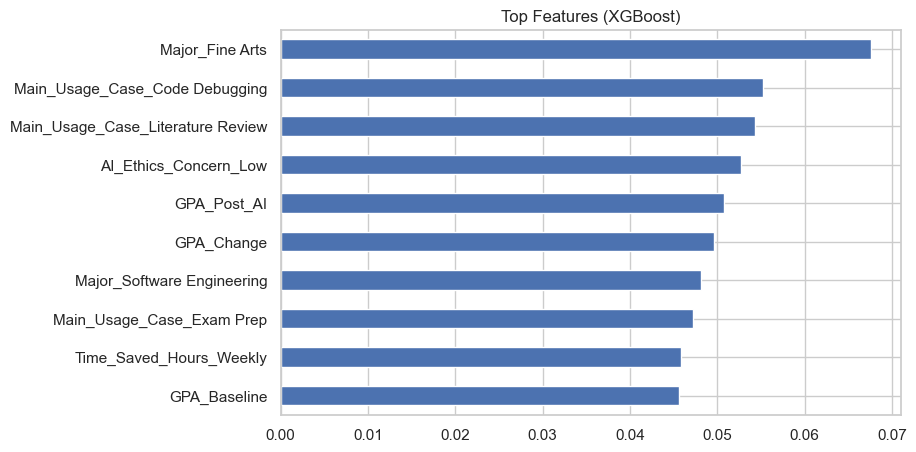

In [30]:
#📊 Feature Importance
importance = pd.Series(xgb_model.feature_importances_, index=X.columns)
importance.sort_values().tail(10).plot(kind='barh', figsize=(8,5))
plt.title("Top Features (XGBoost)")
plt.show()

XGBoost highlights which behaviors (like time saved or usage frequency) most influence career confidence.

# **Clustering Students by Behavior**
We’ll group students based on usage patterns.

In [31]:
#Select Features for Clustering
cluster_features = [
    "Task_Frequency_Daily",
    "Time_Saved_Hours_Weekly",
    "GPA_Change"
]

X_cluster = df_model[cluster_features]

In [32]:
#Scale Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

In [33]:
#KMeans Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

c:\Users\Vanshika\.jupyter\New folder\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


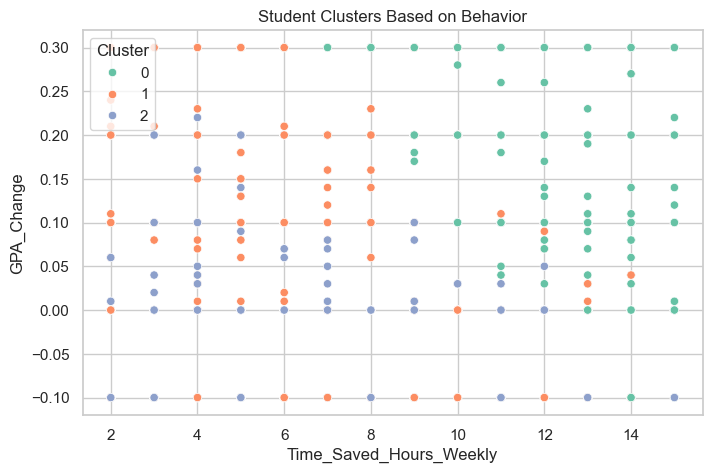

In [34]:
#📊 Visualize Clusters
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df["Time_Saved_Hours_Weekly"],
    y=df["GPA_Change"],
    hue=df["Cluster"],
    palette="Set2"
)
plt.title("Student Clusters Based on Behavior")
plt.show()

Interpret Clusters 

* Cluster 0: Low usage, minimal GPA change
* Cluster 1: High efficiency, strong GPA improvement
* Cluster 2: Heavy usage, mixed academic results

# **GPA Prediction Model**
Now predict GPA_Post_AI

In [35]:
from sklearn.ensemble import RandomForestRegressor

X_gpa = df_model.drop(["GPA_Post_AI"], axis=1)
y_gpa = df_model["GPA_Post_AI"]

X_train, X_test, y_train, y_test = train_test_split(
    X_gpa, y_gpa, test_size=0.2, random_state=42
)

gpa_model = RandomForestRegressor(n_estimators=200, random_state=42)
gpa_model.fit(X_train, y_train)

y_pred = gpa_model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.9997673171619077
RMSE: 0.006793700513465801


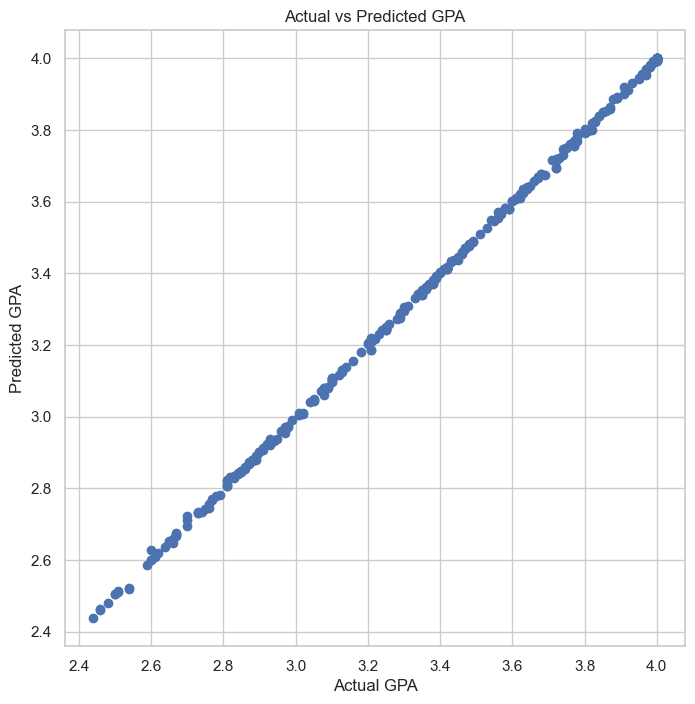

In [36]:
#📊 Actual vs Predicted Plot
plt.figure(figsize=(8,8))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual GPA")
plt.ylabel("Predicted GPA")
plt.title("Actual vs Predicted GPA")
plt.show()

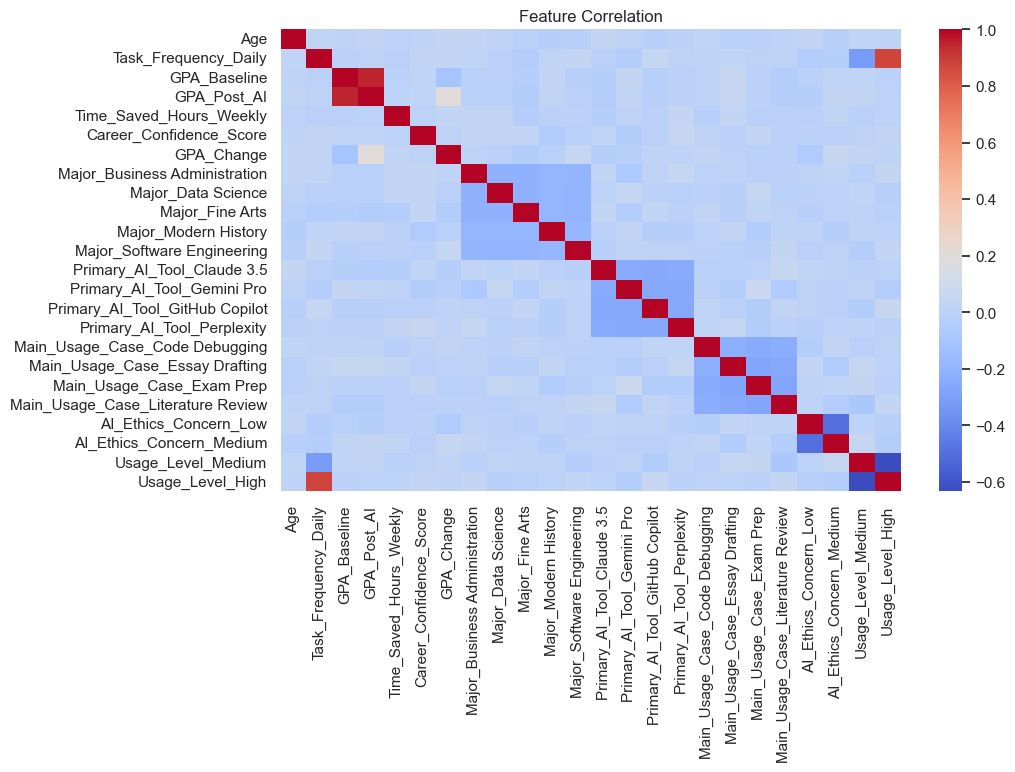

In [37]:
plt.figure(figsize=(10,6))
sns.heatmap(df_model.corr(), cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

**Final Insights**

* AI usage has a measurable but varied impact on GPA
* Time saved is one of the strongest predictors of career confidence
* Not all heavy users perform better—efficiency matters more than frequency
* Clustering reveals distinct student behavior patterns in AI adoption

# **Key Findings**

🔑 Key Takeaways:
* AI usage shows a moderate positive effect on GPA.
* Students using AI for coding/debugging often gain more academically.
* Time saved correlates with higher career confidence.
* Ethical concerns vary with usage intensity.

# **Conclusion**


* AI is not just a tool—it’s becoming a learning partner.
* However, its impact depends heavily on how students use it.